# 26 — Compare Average Motion by Activity

## Goal
To use group statistics and a bar chart to compare activities.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "raw" / "motionsense_raw.csv"
CLEAN_PATH = DATA_DIR / "processed" / "motionsense_clean.csv"
ML_READY_PATH = DATA_DIR / "processed" / "motionsense_ml_ready.csv"
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Group statistics
Instead of reading every row, we summarize each activity group.

This helps answer:

> Which activity has the highest average movement?

In [2]:
df = pd.read_csv(CLEAN_PATH)

# Calculate average motion features for each activity.
activity_summary = (
    df.groupby("activity")
    .agg(
        observations=("activity", "count"),
        avg_acc_magnitude=("acc_magnitude", "mean"),
        avg_gyro_magnitude=("gyro_magnitude", "mean")
    )
    .round(3)
)

activity_summary

,observations,avg_acc_magnitude,avg_gyro_magnitude
activity,,,
Laying,220,0.253,0.031
Sitting,220,0.997,0.045
Standing,220,1.003,0.040
Walking,220,1.184,0.280
Walking Downstairs,220,1.308,0.295
Walking Upstairs,220,1.397,0.325


In [3]:
# Sort activities from highest to lowest average acceleration.
sorted_summary = activity_summary.sort_values(by="avg_acc_magnitude", ascending=False)
sorted_summary

,observations,avg_acc_magnitude,avg_gyro_magnitude
activity,,,
Walking Upstairs,220,1.397,0.325
Walking Downstairs,220,1.308,0.295
Walking,220,1.184,0.280
Standing,220,1.003,0.040
Sitting,220,0.997,0.045
Laying,220,0.253,0.031


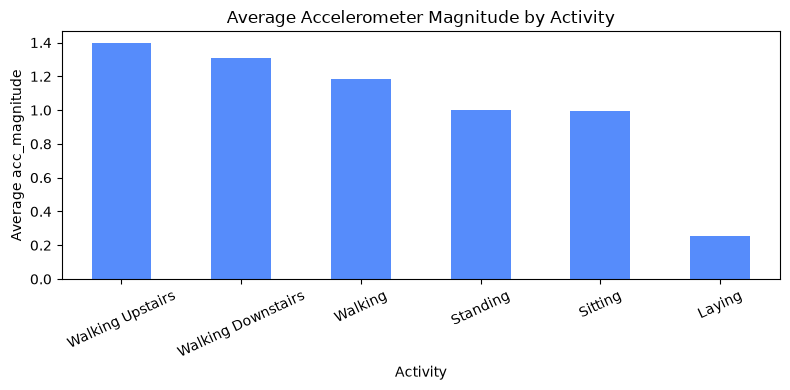

In [4]:
# Visualize average acceleration by activity.
sorted_summary["avg_acc_magnitude"].plot(kind="bar", figsize=(8, 4))
plt.title("Average Accelerometer Magnitude by Activity")
plt.xlabel("Activity")
plt.ylabel("Average acc_magnitude")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Summary
Group summaries make thousands of rows easier to understand.